In [15]:
import os
import re
import pandas as pd

def extract_dates_from_filenames(folder_path):
    date_pattern = re.compile(r'\d{4}-\d{2}-\d{2}')
    dates = []
    
    for filename in os.listdir(folder_path):
        match = date_pattern.search(filename)
        if match:
            dates.append(match.group(0))
    
    return dates

def find_missing_and_duplicate_dates(folder_path, start_date, end_date):
    extracted_dates = extract_dates_from_filenames(folder_path)
    date_counts = pd.Series(extracted_dates).value_counts()
    
    all_dates = pd.date_range(start=start_date, end=end_date).strftime('%Y-%m-%d').tolist()
    existing_dates = set(extracted_dates)
    missing_dates = sorted(set(all_dates) - existing_dates)
    duplicate_dates = date_counts[date_counts > 1].index.tolist()

    missing_dates = [pd.to_datetime(date).strftime('%d-%m-%Y') for date in missing_dates]
    
    return missing_dates, duplicate_dates

# Contoh penggunaan
folder_path = "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Lubang Buaya"  # Ganti dengan path yang sesuai
missing_dates, duplicate_dates = find_missing_and_duplicate_dates(folder_path, "2022-01-01", "2025-01-01")
print("Tanggal yang tidak ada:")
print(len(missing_dates))
print(sorted(missing_dates))
print("Tanggal yang duplikat:")
print(sorted(duplicate_dates))

Tanggal yang tidak ada:
0
[]
Tanggal yang duplikat:
[]


In [6]:
# untuk hapus data yang duplikat

import os
import re
import pandas as pd

def extract_dates_from_filenames(folder_path):
    date_pattern = re.compile(r'\d{4}-\d{2}-\d{2}')
    date_counts = {}
    
    for filename in os.listdir(folder_path):
        match = date_pattern.search(filename)
        if match:
            date = match.group(0)
            if date in date_counts:
                date_counts[date].append(filename)
            else:
                date_counts[date] = [filename]
    
    # Hapus file duplikat
    for date, files in date_counts.items():
        if len(files) > 1:
            for file in files[1:]:
                os.remove(os.path.join(folder_path, file))
    
    return list(date_counts.keys())

def find_missing_dates(folder_path, start_date, end_date):
    extracted_dates = extract_dates_from_filenames(folder_path)
    all_dates = pd.date_range(start=start_date, end=end_date).strftime('%Y-%m-%d').tolist()
    missing_dates = sorted(set(all_dates) - set(extracted_dates))
    
    return missing_dates

# Contoh penggunaan
folder_path = "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\US Embassy 2"  # Ganti dengan path yang sesuai
missing_dates = find_missing_dates(folder_path, "2022-01-01", "2025-01-01")
print("Tanggal yang tidak ada:")
print(missing_dates)

Tanggal yang tidak ada:
[]


In [26]:
import os
import pandas as pd
import re

def gabungkan_csv(folder_sumber, file_output):
    """
    Menggabungkan semua file CSV dalam folder_sumber menjadi satu file CSV dengan tambahan kolom 'datetime'.
    
    Parameters:
        folder_sumber (str): Path folder yang berisi file CSV.
        file_output (str): Nama file output yang akan disimpan.
    
    Returns:
        None
    """
    # Pastikan folder sumber ada
    if not os.path.exists(folder_sumber):
        print(f"Folder '{folder_sumber}' tidak ditemukan.")
        return

    # Dapatkan daftar file CSV dalam folder sumber
    file_csv = [f for f in os.listdir(folder_sumber) if f.endswith(".csv")]

    # Periksa apakah ada file CSV di folder
    if not file_csv:
        print(f"Tidak ada file CSV dalam folder '{folder_sumber}'.")
        return

    # Buat list untuk menyimpan data
    data_list = []

    # Loop untuk membaca dan menggabungkan file CSV
    for file in file_csv:
        file_path = os.path.join(folder_sumber, file)
        
        # Baca file CSV
        df = pd.read_csv(file_path)
        
        # Ekstrak tanggal dari nama file (format: YYYY-MM-DD)
        match = re.search(r"\d{4}-\d{2}-\d{2}", file)
        if match:
            tanggal = match.group(0)
        else:
            print(f"Skipping file {file}, no valid date found in filename.")
            continue

        # Pastikan kolom waktu ada dalam dataset (ganti 'Waktu' sesuai nama kolom di file)
        if "Waktu" in df.columns:
            # Gabungkan tanggal dari nama file dengan waktu dari kolom dalam file
            df["datetime"] = pd.to_datetime(tanggal + " " + df["Waktu"], errors='coerce', utc=True)
            # Format ke ISO 8601 dengan tambahan 'Z' untuk UTC
            df["datetime"] = df["datetime"].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
        else:
            print(f"Skipping file {file}, column 'Waktu' not found.")
            continue

        # Simpan data ke dalam list
        data_list.append(df)

    # Gabungkan semua dataframe menjadi satu
    if data_list:
        final_df = pd.concat(data_list, ignore_index=True)
        # Simpan hasil gabungan ke file CSV
        final_df.to_csv(file_output, index=False)
        print(f"Penggabungan selesai! Data tersimpan di: {file_output}")
    else:
        print("Tidak ada data yang berhasil digabungkan.")

gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Bundaran HI CSV", "merged_data_Bundaran HI.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Jagakarsa CSV", "merged_data_Jagakarsa.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Jakarta GBK CSV", "merged_data_Jakarta GBK.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Kebun Jeruk CSV", "merged_data_Kebun Jeruk.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Kelapa Gading CSV", "merged_data_Kelapa Gading.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\Lubang Buaya CSV", "merged_data_Lubang Buaya.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\US Embassy 1 CSV", "merged_data_US Embassy 1.csv")
gabungkan_csv("C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data pm2.5\\US Embassy 2 CSV", "merged_data_US Embassy 2.csv")


Penggabungan selesai! Data tersimpan di: merged_data_Bundaran HI.csv
Penggabungan selesai! Data tersimpan di: merged_data_Jagakarsa.csv
Penggabungan selesai! Data tersimpan di: merged_data_Jakarta GBK.csv
Penggabungan selesai! Data tersimpan di: merged_data_Kebun Jeruk.csv
Penggabungan selesai! Data tersimpan di: merged_data_Kelapa Gading.csv
Penggabungan selesai! Data tersimpan di: merged_data_Lubang Buaya.csv
Penggabungan selesai! Data tersimpan di: merged_data_US Embassy 1.csv
Penggabungan selesai! Data tersimpan di: merged_data_US Embassy 2.csv


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ispu_pm25(file_merged, nama_stasiun):
    """
    Membuat boxplot ISPU PM2.5 berdasarkan waktu (jam) dari file CSV, 
    dengan mengabaikan nilai 0 agar tidak mempengaruhi visualisasi.

    Parameters:
        file_merged (str): Path file CSV hasil gabungan.
        nama_stasiun (str): Nama stasiun untuk ditampilkan dalam judul plot.

    Returns:
        None
    """
    # Baca file CSV
    try:
        df = pd.read_csv(file_merged)
    except FileNotFoundError:
        print(f"File '{file_merged}' tidak ditemukan.")
        return

    # Pastikan kolom yang diperlukan ada
    if "Waktu" not in df.columns or "ISPU PM2.5" not in df.columns:
        print("Kolom 'Waktu' atau 'ISPU PM2.5' tidak ditemukan dalam data.")
        return

    # Hapus nilai '-' dan konversi ISPU PM2.5 ke numerik
    df = df[df["ISPU PM2.5"] != "-"]
    df["ISPU PM2.5"] = pd.to_numeric(df["ISPU PM2.5"], errors='coerce')

    # Hapus data dengan nilai 0 pada ISPU PM2.5
    df = df[df["ISPU PM2.5"] > 0]

    # Sorting waktu agar selalu berurutan dari 00:00 hingga 23:00
    order_waktu = [f"{str(i).zfill(2)}:00" for i in range(24)]  # List jam dari 00:00 sampai 23:00
    df["Waktu"] = pd.Categorical(df["Waktu"], categories=order_waktu, ordered=True)

    # Buat boxplot dengan seaborn
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df["Waktu"], y=df["ISPU PM2.5"], order=order_waktu)

    # Format plot
    plt.xticks(rotation=45)  # Rotasi label waktu agar lebih mudah dibaca
    plt.xlabel("Waktu (Jam)")
    plt.ylabel("ISPU PM2.5")
    plt.title(f"Boxplot ISPU PM2.5 Berdasarkan Waktu\nStasiun: {nama_stasiun}")

    # Tampilkan plot
    plt.show()

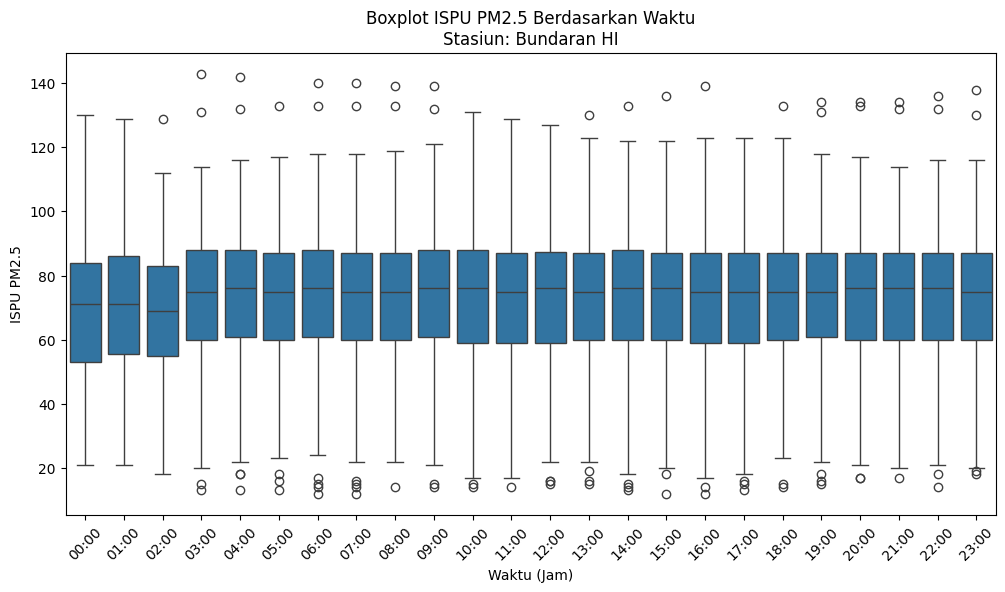

In [44]:
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_Bundaran HI.csv",
    "Bundaran HI"
)

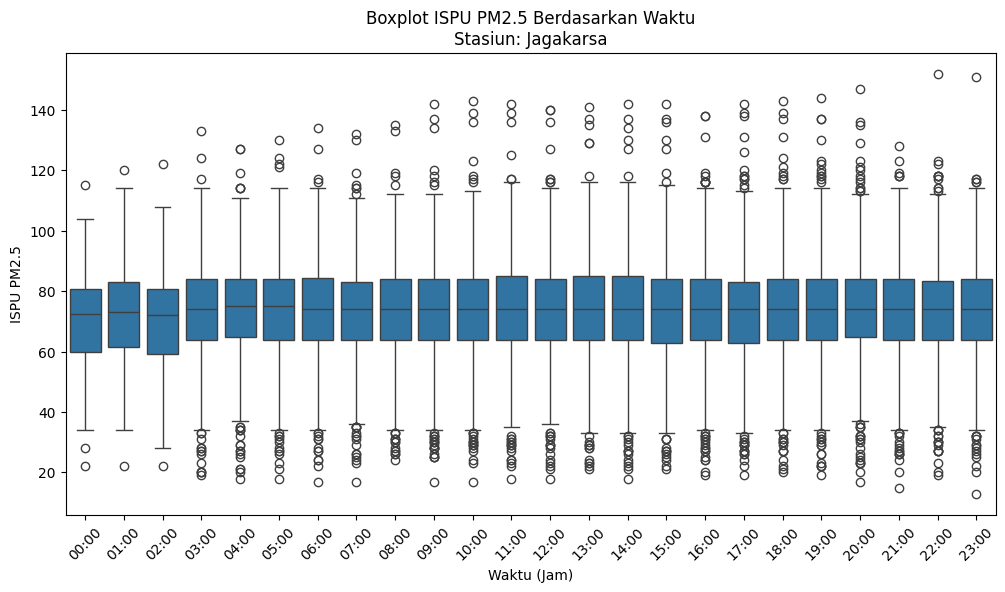

In [45]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_Jagakarsa.csv",
    "Jagakarsa"
)

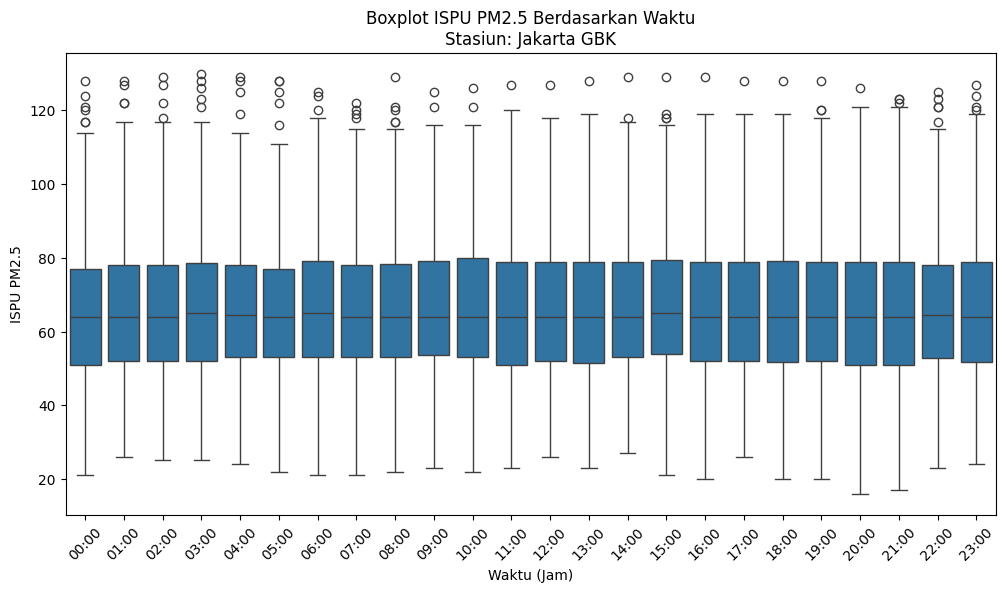

In [46]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_Jakarta GBK.csv",
    "Jakarta GBK"
)

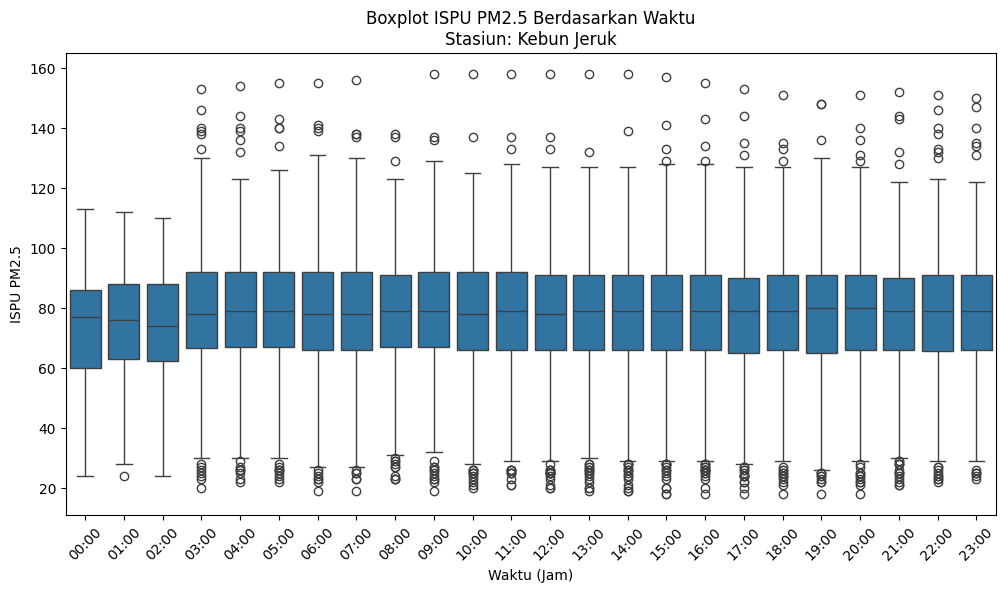

In [47]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_Kebun Jeruk.csv",
    "Kebun Jeruk"
)

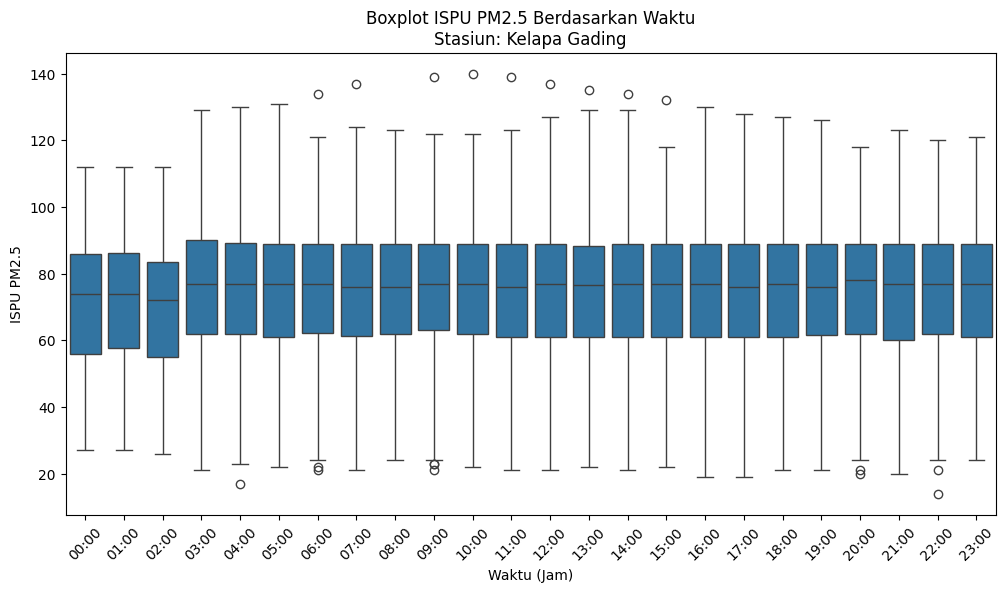

In [48]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_Kelapa Gading.csv",
    "Kelapa Gading"
)

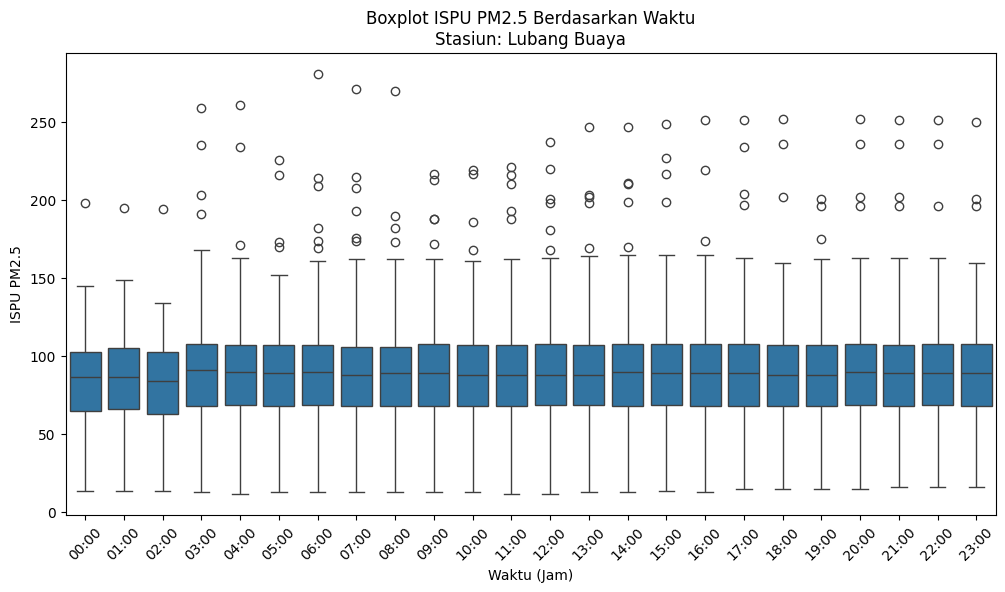

In [49]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_Lubang Buaya.csv",
    "Lubang Buaya"
)

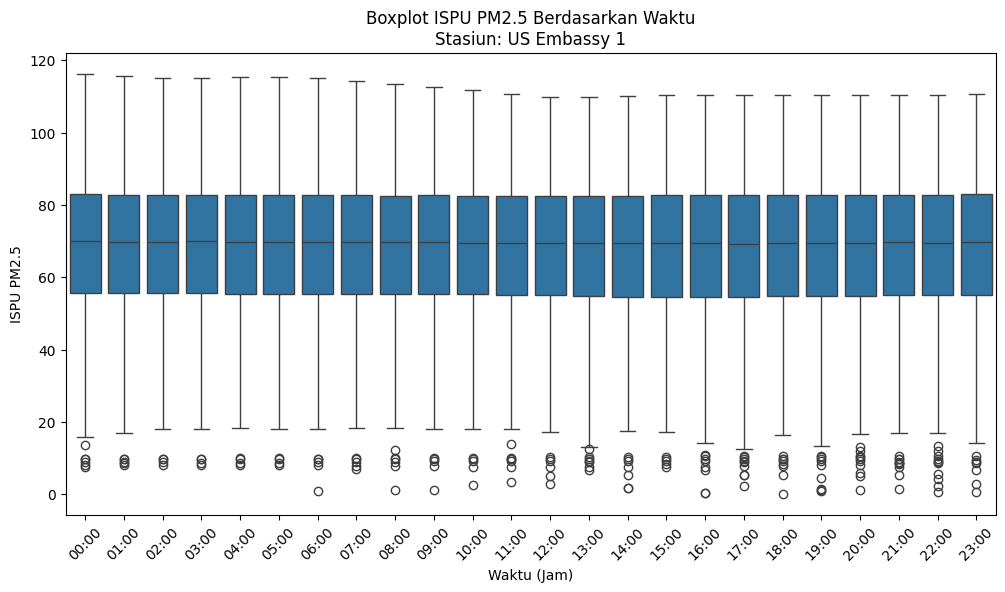

In [50]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_US Embassy 1.csv",
    "US Embassy 1"
)

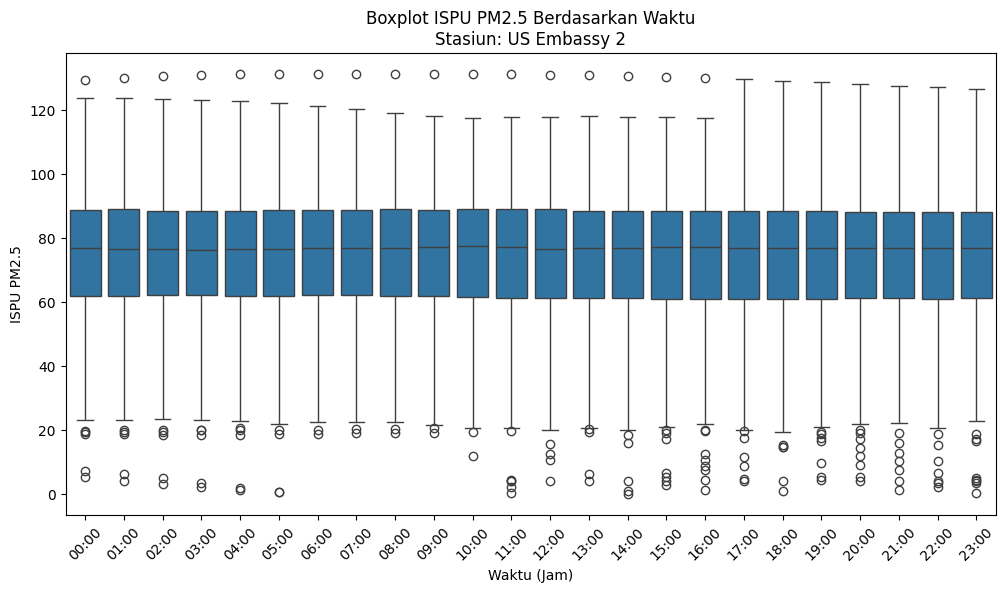

In [51]:
# Contoh pemanggilan fungsi
plot_ispu_pm25(
    "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\merged data pm2.5\\merged_data_US Embassy 2.csv",
    "US Embassy 2"
)